## Przygotowanie

Przed rozpoczęciem pracy z notatnikiem proszę zmienić jego nazwę dodając na początku numer albumu, imię i nazwisko.
{nr_albumu}\_{imię}\_{nazwisko}\_{nazwa}

Po wykonaniu wszystkich zadań proszę przesłać wypełniony notatnik przez platformę ELF za pomocą formularza "Prześlij projekt" w odpowiedniej sekcji. 

## Regresja liniowa wieloraka

Rzadko kiedy zdarza się taka sytuacja, że zależność opisuje się na podstawie tylko jednej zmiennej. Z reguły na wynik zmiennej objaśnianej ($y$) ma wpły więcej różnych cech. Przykładowo, na cenę samochodu ma wpływ rok produkcji, przebieg, ilość koni mechanicznych itp. Dlatego właśnie jest naturalna potrzeba rozwinięcia algorytmu regresji liniowej z jedną cechą na większą ilość cech.

Algorytm, który implementowaliśmy w poprzednim zadaniu jest szczególnym przypadkiem regresji liniowej, ale może zostać on w łatwy sposób uogólniony. Mechanizmy, które poznaliśmy wcześniej takie jak obliczanie funkcji błędu, pochodnych cząstkowych, w dalszym ciągu są aktualne. Trzeba jedynie uwzględnić dodatkowe cechy.

### Zadanie 1

W zbiorze danych z zarobkami, który wykorzystywany był w poprzednim zadaniu, znajduje się pominięta wcześniej cecha. Wczytaj dane z pliku Salary.csv, tym razem z dwiema zmiennymi objaśniającymi: YearsExperience i Age oraz zmienną objaśnianą Salary. Stwórz wykres 3D przedstawiający dane.

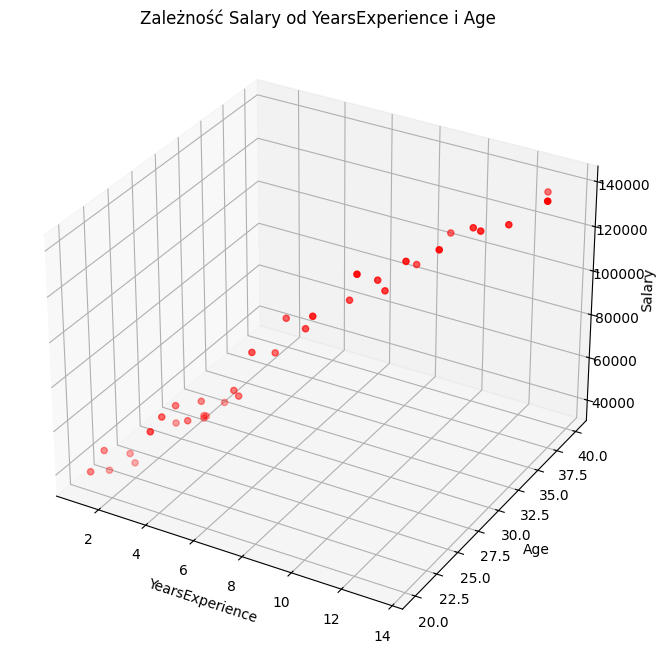

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('Salary.csv')

#YOUR CODE HERE

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['YearsExperience'], df['Age'], df['Salary'], c='r', marker='o')

ax.set_xlabel('YearsExperience')
ax.set_ylabel('Age')
ax.set_zlabel('Salary')

plt.title('Zależność Salary od YearsExperience i Age')
plt.show()

## Zadanie 2

Przerób algorytm znajdujący się w funkcji _learn_and_fit(x,y)_ w taki sposób, aby uwzględniał dodatkową cechę.
Funkcja regresji liniowej przybierze w tym momencie postać:

\begin{equation}
f(x^{(i)}) = \beta_{0} + \beta_{1}x_1 + \beta_{2}x_2 = \beta_{0} + \beta_{1} YearsExperience + \beta_{2} Age
\end{equation}

Pojawienie się kolejnej cechy wymaga akutalizacji obliczania gradientu. Należy dodatkowo obliczyć pochodną cząstkową względem parametru $\beta_{2}$, a następnie zaktualizować wartość tego parametru. 

Obliczenie pochodnej cząstkowej wygląda analogicznie jak w przypadku parametru $\beta_{1}$.

\begin{equation}
    \frac{\partial SSR}{\partial \beta_{2}} = \frac{1}{n} \sum^{n}_{i=1} (f(x^{(i)}) - y^{(i)})x_{1}^{(i)}
\end{equation}

Aktualizacja wartości współczynnika również jest analogiczna.

\begin{equation}
    \beta_{2} = \beta_{2} - \alpha \frac{\partial SSR}{\partial \beta_{2}} 
\end{equation}

_Uwaga: Zastanów się, w jaki sposób zaimplementować obługę kolejnych cech, tak aby po pojawieniu się 3 cechy nie trzeba było modyfikować algorytmu._

In [38]:
import random
from typing import Tuple, List

def initialize_coefficients(n: int = 2, alpha = None) -> Tuple[float, np.ndarray]:
    #YOUR CODE HERE
    betas = np.random.rand(n + 1)
    alpha = alpha if alpha != None else 0.001
    return alpha, betas

def calculate_regression_function(X: np.ndarray, betas: np.ndarray) -> np.ndarray:
    #YOUR CODE HERE
    # return np.dot(X, betas)
    return np.dot(X, betas[1:]) + betas[0]

def calculate_error(X: np.ndarray, y: np.ndarray, betas: np.ndarray) -> float:
    #YOUR CODE HERE
    predictions = calculate_regression_function(X, betas)
    return np.mean((predictions - y) ** 2)

def calculate_gradient(X: np.ndarray, y: np.ndarray, betas: np.ndarray) -> np.ndarray:
    #YOUR CODE HERE
    # n = len(y)
    # predictions = calculate_regression_function(X, betas)
    # gradient = (1 / n) * np.dot(X.T, (predictions - y))
    # return gradient
    predictions = calculate_regression_function(X, betas)
    errors = predictions - y
    gradient = np.zeros_like(betas)
    gradient[0] = np.mean(errors)  # Pochodna dla beta_0
    for i in range(1, len(betas)):
        gradient[i] = np.mean(errors * X[:, i-1]) # Pochodna dla beta_i
    return gradient


def update_regression_coefficients(X: np.ndarray, y: np.ndarray, betas: np.ndarray, alpha: float) -> np.ndarray:
    #YOUR CODE HERE
    gradient = calculate_gradient(X, y, betas)
    betas = betas - alpha * gradient
    return betas

In [ ]:
'''
input:
X - wartości zmiennych objaśniających YearsExperience oraz Age dla wszystkich obserwacji
y - wartości zmiennej objaśnianej Salary dla wszystkich obserwacji

output:
b0: [] - lista z współczynnikami beta_0 w każdej z epok
betas: [] - lista z współczynnikami beta_1, beta_2 w każdej z epok
error: [] - lista z błędem w każdej epoce
'''
def learn_and_fit(X: np.ndarray, y: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    #YOUR CODE HERE
    epochs = 1000

    n_features = X.shape[1]
    alpha, betas = initialize_coefficients(n_features)

    b0_history = []
    betas_history = []
    error_history = []

    for _ in range(epochs):
        b0_history.append(betas[0])
        betas_history.append(betas[1:])
        error_history.append(calculate_error(X, y, betas))

        betas = update_regression_coefficients(X, y, betas, alpha)

    return b0_history, betas_history, error_history

### Zadanie 3

Do stworzonego z zadaniu 1 wykresu dodaj płaszczyznę regresji. Stwórz 3 wykresy przedstawiające jak zmieniała się funkcja regresji na przestrzeni epok (pierwsza, środkowa, ostatnia epoka).

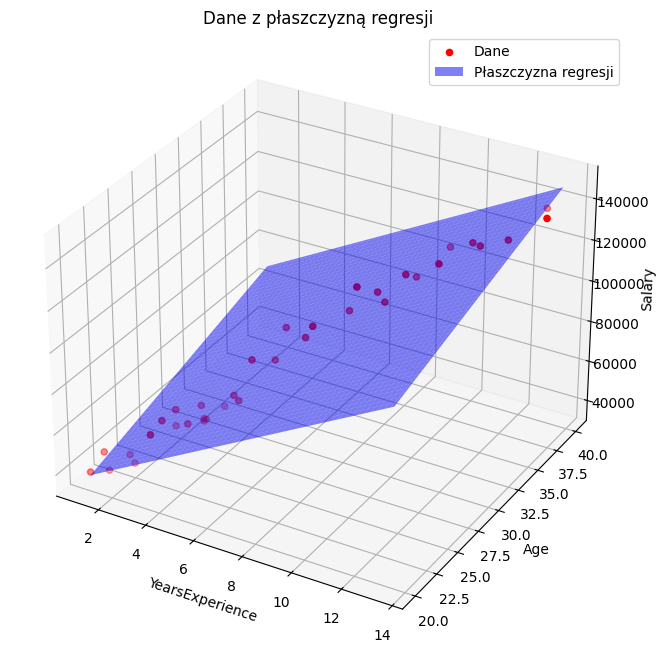

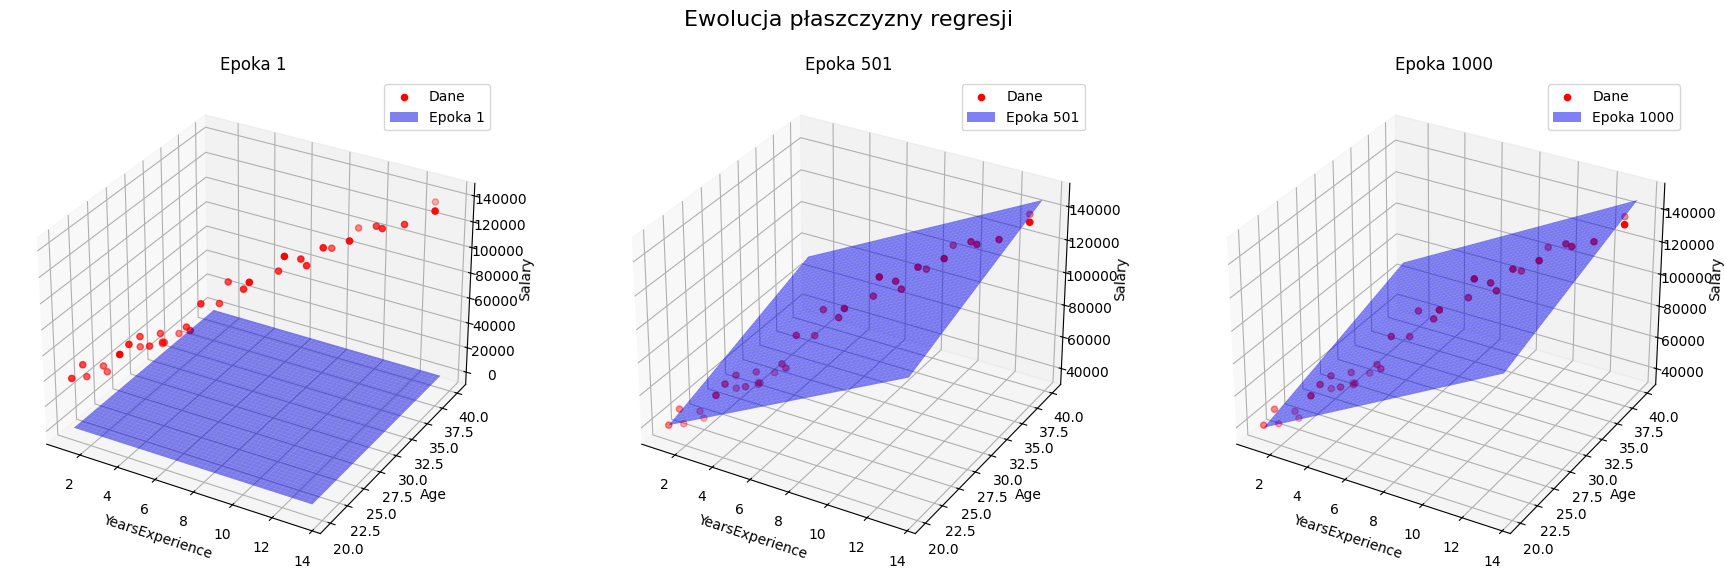

In [40]:
#YOUR CODE HERE

X = df[['YearsExperience', 'Age']].values
y = df['Salary'].values

# Uczenie modelu
b0_history, betas_history, error_history = learn_and_fit(X, y)

# Wygenerowanie płaszczyzny regresji dla ostatniej epoki
x_surf = np.linspace(df['YearsExperience'].min(), df['YearsExperience'].max(), 100)
y_surf = np.linspace(df['Age'].min(), df['Age'].max(), 100)
X_surf, Y_surf = np.meshgrid(x_surf, y_surf)
Z_surf = betas_history[-1][0] * X_surf + betas_history[-1][1] * Y_surf + b0_history[-1]

# Dodanie płaszczyzny regresji do wykresu 3D
fig_regression = plt.figure(figsize=(10, 8))
ax_regression = fig_regression.add_subplot(111, projection='3d')

ax_regression.scatter(df['YearsExperience'], df['Age'], df['Salary'], c='r', marker='o', label='Dane')
ax_regression.plot_surface(X_surf, Y_surf, Z_surf, color='blue', alpha=0.5, label='Płaszczyzna regresji')

ax_regression.set_xlabel('YearsExperience')
ax_regression.set_ylabel('Age')
ax_regression.set_zlabel('Salary')

plt.title('Dane z płaszczyzną regresji')
ax_regression.legend()
plt.show()

# Wykresy zmian funkcji regresji na przestrzeni epok
epochs_to_plot = [0, len(b0_history) // 2, -1] # Pierwsza, środkowa i ostatnia epoka
fig_evolution, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={'projection': '3d'})
fig_evolution.suptitle('Ewolucja płaszczyzny regresji', fontsize=16)

x_surf = np.linspace(df['YearsExperience'].min(), df['YearsExperience'].max(), 50)
y_surf = np.linspace(df['Age'].min(), df['Age'].max(), 50)
X_surf_plot, Y_surf_plot = np.meshgrid(x_surf, y_surf)

for i, epoch_index in enumerate(epochs_to_plot):
    b0 = b0_history[epoch_index]
    betas = betas_history[epoch_index]
    Z_surf_plot = betas[0] * X_surf_plot + betas[1] * Y_surf_plot + b0
    ax = axes[i]
    ax.scatter(df['YearsExperience'], df['Age'], df['Salary'], c='r', marker='o', label='Dane')
    ax.plot_surface(X_surf_plot, Y_surf_plot, Z_surf_plot, color='blue', alpha=0.5, label=f'Epoka {epoch_index + 1 if epoch_index != -1 else len(b0_history)}')
    ax.set_xlabel('YearsExperience')
    ax.set_ylabel('Age')
    ax.set_zlabel('Salary')
    ax.set_title(f'Epoka {epoch_index + 1 if epoch_index != -1 else len(b0_history)}')
    ax.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()


### Zadanie 4

W sytuacji, w której zbiór danych zawiera więcej zmiennych objaśniających niż 2, niemożliwym staje się wizualizacja prostej regresji i ocena w taki sposób stworzonego modelu. Bardzo przydatnym rozwiązaniem jest wtedy stworzenie wykresu błędów regresji. Jeśli wartości błędu spadają wraz z kolejnymi epokami, oznacza to, że jesteśmy na dobrej drodze, a nasz algorytm działa poprawnie. Celem tego zadania będzie stworzenie finalnego modelu regresji liniowej, który będzie przyjmował dowolną liczbę zmiennych objaśniających.

Na podstawie wcześniejszych implementacji, stwórz implementację funkcji *learn_and_fit_multi(X, y)*, która będzie przyjmować zbiór wejściowy z dowolną ilością kolum (cech). Dla takiego zbioru zbioru danych ma zostać stworzony model regresji. Funkcja podobnie jak wcześniej, ma zwracać współczynniki oraz wartość błędu w każdej epoce. 

W notebooku z opisem regresji liniowej przedstawione zostały wzory na ogólą postać regresji. Przeanalizuj je jeszcze raz i postaraj się je zaimplementować.

Wczytaj zestaw danych *multi_variable_regression.csv* z katalogu datasets. Dane wygenerowane zostały w taki sposób, że są wysoce liniowo zależne. Wartość błędu dla nauczonego modelu powinna być w takim przypadku niewielka. Przetestuj na wczytanym zbiorze swój algorytm.

In [41]:
#YOUR CODE HERE

def learn_and_fit_multi(X: np.ndarray, y: np.ndarray, alpha: List[float] = None) -> tuple[np.ndarray, list[float]]:
    n_features = X.shape[1]
    if alpha == None:
        alpha, betas = initialize_coefficients(n_features)
    else:
        _, betas = initialize_coefficients(n_features)
    error_history = []

    epochs = 10000

    for _ in range(epochs):
        error_history.append(calculate_error(X, y, betas))
        betas = update_regression_coefficients(X, y, betas, alpha)

    return betas, error_history

### Zadanie 5

Stwórz wykres przedstawiający zmianę błędu regresji w kolejnych epokach. Napisz co można na jego podstawie wywnioskować.

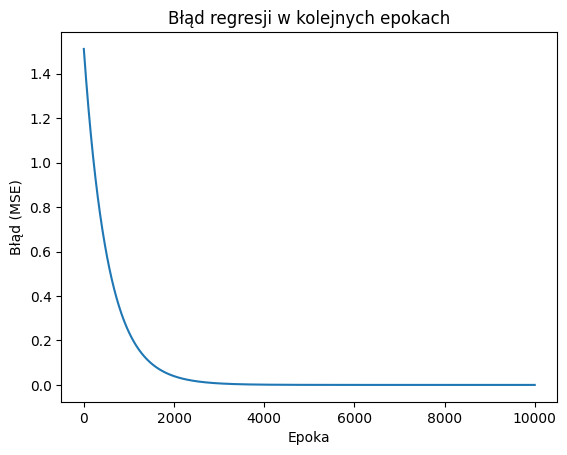

In [42]:
#YOUR CODE HERE
df = pd.read_csv('multi_variable_regression.csv', sep=',')
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
y = (y - np.mean(y)) / np.std(y)

betas, error_history = learn_and_fit_multi(X, y)

# Wykres błędu
plt.plot(error_history)
plt.xlabel('Epoka')
plt.ylabel('Błąd (MSE)')
plt.title('Błąd regresji w kolejnych epokach')
plt.show()

In [ ]:
Na początek błąd szybko maleje, a następnie stabilizuje się w okolicach zera

### Zadanie 6

W jaki sposób współczynnik alpha wpływa na działania algorytmu? Przeprowadź eksperyment dla minimum trzech różnych wartości tego parametru. Sformułuj wnioski. Jak zmiana parametru wpłynęła na ilość epok w algorytmie? Jak zmieniła się funkcja regresji?


Uczenie z alpha = 0.0001
Ostatni błąd (MSE): 0.1856
Nauczone współczynniki: [0.00988268 0.42973829 0.62015998 0.31399328 0.53965434 0.31772206
 0.61826693]

Uczenie z alpha = 0.005
Ostatni błąd (MSE): 0.0000
Nauczone współczynniki: [-2.77459764e-17  3.18908437e-01  4.39734365e-01  2.33457369e-02
  5.05713331e-01  4.43806614e-02  5.34837201e-01]

Uczenie z alpha = 0.02
Ostatni błąd (MSE): 0.0000
Nauczone współczynniki: [-5.51557038e-17  3.18908437e-01  4.39734365e-01  2.33457369e-02
  5.05713331e-01  4.43806614e-02  5.34837201e-01]


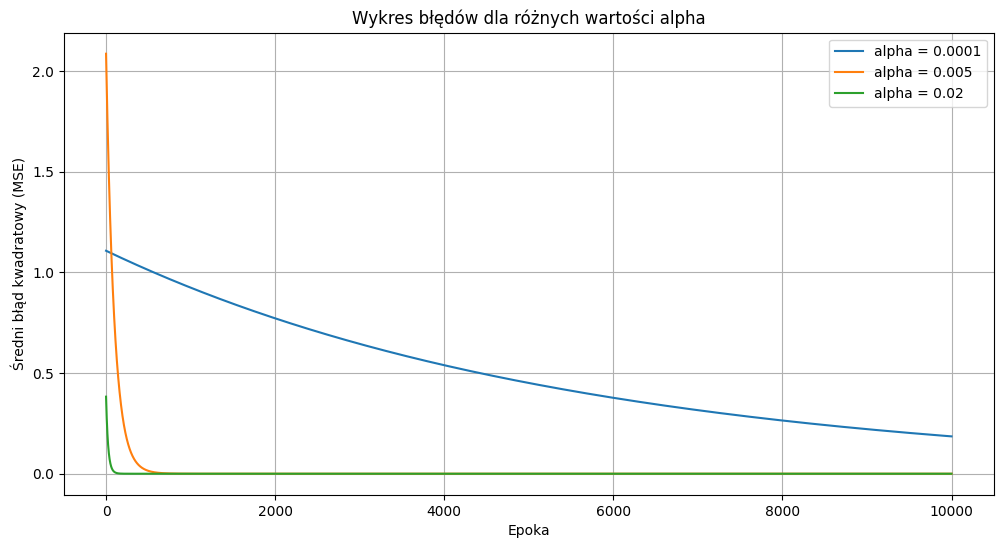

In [43]:
# YOUR CODE HERE

alpha_values = [0.0001, 0.005, 0.02]

plt.figure(figsize=(12, 6))

learned_betas_all = {}
error_histories_all = {}

for alpha in alpha_values:
    print(f"\nUczenie z alpha = {alpha}")
    learned_betas, error_history = learn_and_fit_multi(X, y, alpha)
    learned_betas_all[alpha] = learned_betas
    error_histories_all[alpha] = error_history
    plt.plot(range(len(error_history)), error_history, label=f'alpha = {alpha}')
    print(f"Ostatni błąd (MSE): {error_history[-1]:.4f}")
    print(f"Nauczone współczynniki: {learned_betas}")

plt.xlabel('Epoka')
plt.ylabel('Średni błąd kwadratowy (MSE)')
plt.title('Wykres błędów dla różnych wartości alpha')
plt.legend()
plt.grid(True)
plt.show()

### Zadanie 7

Porównaj czas działania algorytmu we własnej implementacji oraz implementacji z biblioteki Sklearn.

In [44]:
# YOUR CODE HERE
import time
from sklearn.linear_model import LinearRegression

# 1. Moja implementacja
print("Uruchamianie mojej implementacji...")
start_time_own = time.time()
learned_betas_own, error_history_own = learn_and_fit_multi(X, y)
end_time_own = time.time()
time_own = end_time_own - start_time_own
print(f"Czas działania Twojej implementacji: {time_own:.4f} sekundy")
print(f"Ostatni błąd (MSE) Twojej implementacji: {error_history_own[-1]:.4f}")
print(f"Nauczone współczynniki (pierwsze kilka) Twojej implementacji: {learned_betas_own[:5]}")

# 2. Implementacja Scikit-learn
print("\nUruchamianie implementacji Scikit-learn...")
model_sklearn = LinearRegression()
start_time_sklearn = time.time()
model_sklearn.fit(X, y)
end_time_sklearn = time.time()
time_sklearn = end_time_sklearn - start_time_sklearn
print(f"Czas działania implementacji Scikit-learn: {time_sklearn:.4f} sekundy")
predictions_sklearn = model_sklearn.predict(X)
mse_sklearn = np.mean((predictions_sklearn - y) ** 2)
print(f"Błąd (MSE) implementacji Scikit-learn: {mse_sklearn:.4f}")
print(f"Nauczone współczynniki (pierwsze kilka) implementacji Scikit-learn: {[model_sklearn.intercept_] + list(model_sklearn.coef_[:4])}")

Uruchamianie mojej implementacji...
Czas działania Twojej implementacji: 0.7282 sekundy
Ostatni błąd (MSE) Twojej implementacji: 0.0000
Nauczone współczynniki (pierwsze kilka) Twojej implementacji: [1.93486130e-05 3.18915653e-01 4.39640922e-01 2.33162578e-02
 5.05742201e-01]

Uruchamianie implementacji Scikit-learn...
Czas działania implementacji Scikit-learn: 0.0014 sekundy
Błąd (MSE) implementacji Scikit-learn: 0.0000
Nauczone współczynniki (pierwsze kilka) implementacji Scikit-learn: [np.float64(-1.8540050740061062e-17), np.float64(0.3189084374885873), np.float64(0.43973436481357686), np.float64(0.023345736933517856), np.float64(0.5057133308770447)]
